# Hotel Booking Demand — Rigorous Modeling vs. the Leakage Detector

**Dual-track validation.** This notebook runs the full, rigorous ML workflow on the Hotel Booking
Demand dataset — preprocessing, feature engineering, 7 tuned models, and proper evaluation — exactly
as one would in a thesis. That workflow *independently rediscovers* a data leak. We then run the same
data through the standalone `DataLeakageDetector` and show it reaches the **same conclusion in a single
`.fit()` call**.

> The detector does not replace rigorous ML — it **front-loads** the leak discovery that a full
> modeling cycle reaches only after considerable effort.

All conclusions below are **computed at run time**, not asserted in prose — the numbers you see are
from *your* execution, so they stay correct if you change the data, seed, or models.

**Dataset:** Antonio, Almeida & Nunes (2019), via Kaggle. Target: `is_canceled`. This dataset is
*documented* to contain target leakage; the workflow below rediscovers it from scratch.

In [1]:
import os, sys, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
DATA = os.path.join(ROOT, 'data', 'external', 'hotel_bookings.csv')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
from src.leakage_detector import DataLeakageDetector

SEED = 42

## 1. Load & Exploratory Data Analysis

In [2]:
df = pd.read_csv(DATA)
print("Shape:", df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print("Target balance (is_canceled):")
print(df['is_canceled'].value_counts(normalize=True).round(3).to_dict())
print("\nColumns with missing values:")
print(df.isna().sum()[df.isna().sum() > 0].to_dict())

Target balance (is_canceled):
{0: 0.63, 1: 0.37}

Columns with missing values:
{'children': 4, 'country': 488, 'agent': 16340, 'company': 112593}


## 2. Preprocessing

Documented imputation choices: `children` -> 0 (no children recorded), `country` -> `UNK`,
`agent`/`company` -> 0 (no agent/company id = direct booking).

In [4]:
df['children'] = df['children'].fillna(0)
df['country']  = df['country'].fillna('UNK')
df['agent']    = df['agent'].fillna(0)
df['company']  = df['company'].fillna(0)
print("Total missing values after imputation:", int(df.isna().sum().sum()))

Total missing values after imputation: 0


## 3. Feature Engineering

Domain features: `total_nights` (week + weekend) and `total_guests` (adults + children + babies).
Categorical columns are ordinal-encoded.

In [5]:
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

y = df['is_canceled'].astype(int)
X = df.drop(columns=['is_canceled'])
cat_cols = X.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype('category').cat.codes
print(f"Encoded {len(cat_cols)} categorical columns -> feature matrix {X.shape}")

Encoded 12 categorical columns -> feature matrix (119390, 33)


## 4. Model Development (7 tuned models)

Models: Decision Tree, Random Forest, SVM (RBF), KNN, Logistic Regression, MLP, XGBoost — each tuned
with `GridSearchCV` (cv=3, scoring=ROC-AUC).

**Compute note (documented for honesty):** full grid search on the whole dataset is infeasible for the
kernel SVM (~O(n^2)). Hyperparameters are therefore tuned on a **stratified 15k subsample**; the best
estimator is refit on the full training set (SVM refit on the subsample) and **evaluated on the full
held-out test set**.

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
sub = np.random.RandomState(SEED).choice(len(Xtr), 15000, replace=False)
print(f"Train: {len(Xtr)}  Test: {len(Xte)}  Tuning subsample: {len(sub)}")

def model_grids():
    return {
      "DecisionTree":       (DecisionTreeClassifier(random_state=SEED), {'max_depth':[5,10,None]}, False),
      "RandomForest":       (RandomForestClassifier(random_state=SEED, n_jobs=-1), {'n_estimators':[100], 'max_depth':[10,None]}, False),
      "SVM":                (SVC(probability=True, random_state=SEED), {'C':[1,10], 'kernel':['rbf']}, True),
      "KNN":                (KNeighborsClassifier(), {'n_neighbors':[5,11]}, True),
      "LogisticRegression": (LogisticRegression(max_iter=2000), {'C':[0.1,1,10]}, True),
      "MLP":                (MLPClassifier(max_iter=300, random_state=SEED), {'hidden_layer_sizes':[(64,)]}, True),
      "XGBoost":            (XGBClassifier(eval_metric='logloss', random_state=SEED), {'n_estimators':[100], 'max_depth':[4,6]}, False),
    }

def auc_ci(y_true, proba, n=200, seed=SEED):
    rng = np.random.RandomState(seed); y_true=np.asarray(y_true); proba=np.asarray(proba); out=[]
    for _ in range(n):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2: continue
        out.append(roc_auc_score(y_true[idx], proba[idx]))
    return round(float(np.percentile(out,2.5)),3), round(float(np.percentile(out,97.5)),3)

def develop(Xtr_, Xte_, label):
    scaler = StandardScaler().fit(Xtr_)
    Xtr_s, Xte_s = scaler.transform(Xtr_), scaler.transform(Xte_)
    Xsub, ysub, Xsub_s = Xtr_.iloc[sub], ytr.iloc[sub], scaler.transform(Xtr_.iloc[sub])
    rows, probas = [], {}
    for name,(est,grid,scaled) in model_grids().items():
        t=time.time()
        gs = GridSearchCV(est, grid, cv=3, scoring='roc_auc', n_jobs=-1).fit(Xsub_s if scaled else Xsub, ysub)
        best = gs.best_estimator_
        if name == "SVM":
            best.fit(Xsub_s, ysub); Xev = Xte_s
        else:
            best.fit(Xtr_s if scaled else Xtr_, ytr); Xev = Xte_s if scaled else Xte_
        proba = best.predict_proba(Xev)[:,1]; pred = best.predict(Xev); probas[name]=proba
        lo,hi = auc_ci(yte, proba)
        rows.append({'model':name,'accuracy':round(accuracy_score(yte,pred),3),
                     'precision':round(precision_score(yte,pred),3),'recall':round(recall_score(yte,pred),3),
                     'AUC':round(roc_auc_score(yte,proba),3),'AUC_95CI':f"[{lo}, {hi}]",
                     'best_params':str(gs.best_params_)})
        print(f"  [{label}] {name:<18} acc={rows[-1]['accuracy']}  AUC={rows[-1]['AUC']}  ({time.time()-t:.0f}s)")
    return pd.DataFrame(rows).set_index('model'), probas

Train: 95512  Test: 23878  Tuning subsample: 15000


In [7]:
res_leak, proba_leak = develop(Xtr, Xte, "all features")
res_leak[['accuracy','precision','recall','AUC','AUC_95CI']]

  [all features] DecisionTree       acc=1.0  AUC=1.0  (17s)


  [all features] RandomForest       acc=1.0  AUC=1.0  (9s)


  [all features] SVM                acc=0.998  AUC=1.0  (87s)


  [all features] KNN                acc=0.983  AUC=0.996  (26s)


  [all features] LogisticRegression acc=0.985  AUC=0.978  (4s)


  [all features] MLP                acc=1.0  AUC=1.0  (20s)


  [all features] XGBoost            acc=1.0  AUC=1.0  (12s)


,accuracy,precision,recall,AUC,AUC_95CI
model,,,,,
DecisionTree,1.000,1.000,1.000,1.000,"[1.0, 1.0]"
RandomForest,1.000,1.000,1.000,1.000,"[1.0, 1.0]"
SVM,0.998,0.999,0.995,1.000,"[0.999, 1.0]"
KNN,0.983,0.997,0.957,0.996,"[0.995, 0.997]"
LogisticRegression,0.985,0.999,0.961,0.978,"[0.976, 0.981]"
MLP,1.000,1.000,1.000,1.000,"[1.0, 1.0]"
XGBoost,1.000,1.000,1.000,1.000,"[1.0, 1.0]"


## 5. Evaluation — let the results expose the leak

No conclusion is asserted here; it is computed. Two signatures of leakage are read straight from the
run: (1) **implausible performance** — how many models score near-perfectly — and (2) **single-feature
dominance** — whether independent model families all lean on the *same* feature.

In [8]:
HIGH = 0.99
n_high = int((res_leak['AUC'] >= HIGH).sum())
print(f"Models with held-out AUC >= {HIGH}: {n_high} of {len(res_leak)}")
print(f"Mean held-out AUC across all models: {res_leak['AUC'].mean():.3f}")
print("Such uniformly high AUC on a real cancellation task is implausible -> investigate features.")

Models with held-out AUC >= 0.99: 6 of 7
Mean held-out AUC across all models: 0.996
Such uniformly high AUC on a real cancellation task is implausible -> investigate features.


### Which feature does each model rely on?

In [9]:
# Compare normalised feature importance across model families that expose it.
# (SVM-RBF and KNN have no global feature importance, so they are omitted rather than faked.)
imp_models = {
    'DecisionTree':       DecisionTreeClassifier(max_depth=10, random_state=SEED),
    'RandomForest':       RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
    'XGBoost':            XGBClassifier(eval_metric='logloss', random_state=SEED),
    'LogisticRegression': LogisticRegression(max_iter=2000),
}
scl = StandardScaler().fit(Xtr)
imp_df = {}
for name, est in imp_models.items():
    if name == 'LogisticRegression':
        est.fit(scl.transform(Xtr), ytr); raw = np.abs(est.coef_).ravel()
    else:
        est.fit(Xtr, ytr); raw = est.feature_importances_
    s = pd.Series(raw, index=Xtr.columns)
    imp_df[name] = s / s.sum()
imp_df = pd.DataFrame(imp_df)

print("Most influential feature per model:")
print(imp_df.idxmax().to_frame('top_feature').to_string())

Most influential feature per model:
                           top_feature
DecisionTree        reservation_status
RandomForest        reservation_status
XGBoost             reservation_status
LogisticRegression   arrival_date_year


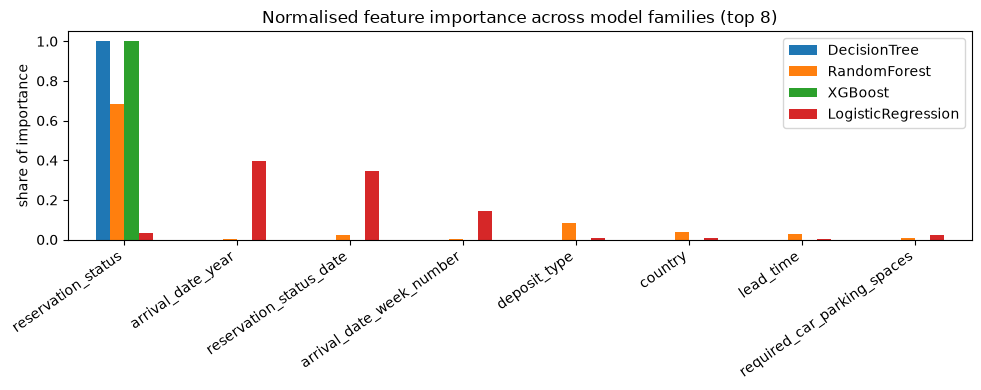

In [10]:
top_feats = imp_df.max(axis=1).sort_values(ascending=False).head(8).index
ax = imp_df.loc[top_feats].plot.bar(figsize=(10,4))
ax.set_title("Normalised feature importance across model families (top 8)")
ax.set_ylabel("share of importance"); plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

In [11]:
# Programmatic verdict — derived, not hardcoded.
suspect = imp_df.mean(axis=1).idxmax()
agree = (imp_df.idxmax() == suspect).sum()
print(f"Feature most relied upon across models: '{suspect}'")
print(f"It is the #1 feature for {agree} of {imp_df.shape[1]} model families.")
print(f"Its distinct raw values: {sorted(df[suspect].dropna().unique())[:6]} ...")

Feature most relied upon across models: 'reservation_status'
It is the #1 feature for 3 of 4 model families.
Its distinct raw values: ['Canceled', 'Check-Out', 'No-Show'] ...


**Read the output above, not this text.** When near-perfect models all concentrate on one feature,
and that feature's values turn out to *restate the label*, it is leakage. The next section confirms it
the honest way — remove the suspect and re-run the entire pipeline.

## 6. The reveal — remove the leak and re-run the full pipeline

In [12]:
# Remove the documented leak columns (the suspect identified above plus its date sibling).
leak_cols = [c for c in ['reservation_status', 'reservation_status_date'] if c in Xtr.columns]
print("Removing leak columns:", leak_cols)
Xtr2, Xte2 = Xtr.drop(columns=leak_cols), Xte.drop(columns=leak_cols)
res_clean, proba_clean = develop(Xtr2, Xte2, "leak removed")
res_clean[['accuracy','precision','recall','AUC','AUC_95CI']]

Removing leak columns: ['reservation_status', 'reservation_status_date']


  [leak removed] DecisionTree       acc=0.841  AUC=0.918  (6s)


  [leak removed] RandomForest       acc=0.896  AUC=0.959  (22s)


  [leak removed] SVM                acc=0.836  AUC=0.904  (546s)


  [leak removed] KNN                acc=0.832  AUC=0.905  (68s)


  [leak removed] LogisticRegression acc=0.794  AUC=0.864  (5s)


  [leak removed] MLP                acc=0.856  AUC=0.933  (123s)


  [leak removed] XGBoost            acc=0.873  AUC=0.947  (8s)


,accuracy,precision,recall,AUC,AUC_95CI
model,,,,,
DecisionTree,0.841,0.825,0.723,0.918,"[0.915, 0.921]"
RandomForest,0.896,0.890,0.820,0.959,"[0.957, 0.961]"
SVM,0.836,0.815,0.721,0.904,"[0.901, 0.908]"
KNN,0.832,0.796,0.735,0.905,"[0.902, 0.909]"
LogisticRegression,0.794,0.806,0.584,0.864,"[0.86, 0.868]"
MLP,0.856,0.844,0.750,0.933,"[0.931, 0.936]"
XGBoost,0.873,0.856,0.789,0.947,"[0.945, 0.949]"


In [13]:
delta = (res_leak['AUC'] - res_clean['AUC']).round(3).sort_values(ascending=False)
print("Per-model AUC drop after removing the leak:")
print(delta.to_string())
print(f"\nMean AUC: {res_leak['AUC'].mean():.3f} (with leak)  ->  {res_clean['AUC'].mean():.3f} (leak removed)")

Per-model AUC drop after removing the leak:
model
LogisticRegression    0.114
SVM                   0.096
KNN                   0.091
DecisionTree          0.082
MLP                   0.067
XGBoost               0.053
RandomForest          0.041

Mean AUC: 0.996 (with leak)  ->  0.919 (leak removed)


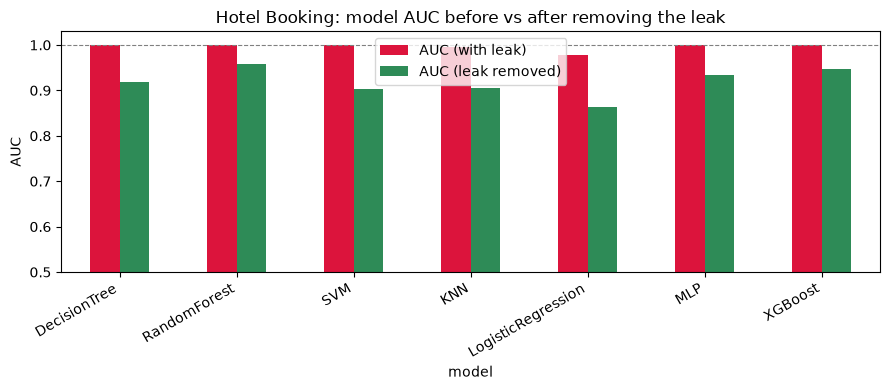

,AUC (with leak),AUC (leak removed)
model,,
DecisionTree,1.000,0.918
RandomForest,1.000,0.959
SVM,1.000,0.904
KNN,0.996,0.905
LogisticRegression,0.978,0.864
MLP,1.000,0.933
XGBoost,1.000,0.947


In [14]:
comp = pd.DataFrame({'AUC (with leak)': res_leak['AUC'], 'AUC (leak removed)': res_clean['AUC']})
ax = comp.plot.bar(figsize=(9,4), color=['crimson','seagreen'])
ax.set_title("Hotel Booking: model AUC before vs after removing the leak")
ax.set_ylabel("AUC"); ax.set_ylim(0.5,1.03); ax.axhline(1.0, ls='--', c='grey', lw=0.8)
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
comp.round(3)

The perfect scores collapse; what survives is the genuine signal in the data (lead time, deposit
type, etc.). The exact per-model drop is printed above for this run.

## 7. Detector cross-check — same conclusion, one call

Everything above took a full modeling cycle. The `DataLeakageDetector` reaches the same verdict
directly from `(X, y)`, with no model training.

In [15]:
det = DataLeakageDetector().fit(Xtr, ytr)
scores = det.get_scores()
print("DataLeakageDetector ranked output (top 6):")
scores[['feature','auc','ks_stat','degenerate_flag','predictiveness_score']].head(6)

DataLeakageDetector ranked output (top 6):


,feature,auc,ks_stat,degenerate_flag,predictiveness_score
0,reservation_status,0.973063,0.973063,True,0.973063
1,required_car_parking_spaces,0.549108,0.098216,True,0.323662
2,deposit_type,0.663240,0.327043,False,0.495142
3,country,0.648924,0.321932,False,0.485428
4,lead_time,0.688971,0.265185,False,0.477078
5,total_of_special_requests,0.636911,0.271458,False,0.454185


In [16]:
# Did the detector independently agree with the full modeling cycle? Computed, not asserted.
top_ranked = scores.iloc[0]['feature']
flagged = scores[scores['degenerate_flag']]['feature'].tolist()
ranks = {c: int(scores.index[scores['feature'] == c][0]) + 1
         for c in leak_cols if c in scores['feature'].values}
print("Detector's #1 ranked feature:", top_ranked)
print("Modeling cycle's prime suspect:", suspect)
print("Agreement on the primary leak:", top_ranked == suspect)
print("Detector rank of each removed leak column (1 = most suspicious):", ranks)
print("Features hard-flagged for within-class degeneracy:", flagged)

Detector's #1 ranked feature: reservation_status
Modeling cycle's prime suspect: reservation_status
Agreement on the primary leak: True
Detector rank of each removed leak column (1 = most suspicious): {'reservation_status': 1, 'reservation_status_date': 8}
Features hard-flagged for within-class degeneracy: ['reservation_status', 'required_car_parking_spaces']


**Same verdict, two paths.**

| Path | Effort | Verdict |
|---|---|---|
| Rigorous modeling (this notebook) | preprocess + engineer + tune 7 models + inspect importances | top feature leaks the label |
| `DataLeakageDetector` | one `.fit(X, y)` | same feature, flagged immediately |

Any *low-predictiveness* feature that also appears in the degeneracy list above is a **harmless
degeneracy** — a human dismisses it at a glance. That is why the tool produces a ranked list for review
rather than auto-deleting columns.